This file ingests the raw data from two datasets:

https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri

https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri?resource=download

The data goes through a sequence of pre processing steps.

1. Rename files for consistency

2. Create directory for storing cropped images

3. Crop images
   - Grayscale
   - Blur
   - Binary threshold
   - Erosion
   - Contours

4. Data augmentation


In [24]:
'''
Imports
'''
import os
import random
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
from IPython.display import Image
import imutils   
import keras
import tensorflow.keras as K
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator, array_to_img, img_to_array

In [32]:
'''
Since the data comes from two sources, we rename each image file to maintain consistency in nomenclature.
1.1 TRAINING
'''
## No tumor
# Specify the directory containing the images
directory = 'Data/Training/no_tumor'

# Iterate through each file in the directory
for index, filename in enumerate(sorted(os.listdir(directory)), start=1):
    # Get the file extension (e.g., .jpg, .png)
    file_extension = os.path.splitext(filename)[1]
    
    # Construct the new filename
    new_name = f"n {index}{file_extension}"
    
    # Get the full file paths
    old_path = os.path.join(directory, filename)
    new_path = os.path.join(directory, new_name)
    
    # Rename the file
    os.rename(old_path, new_path)
    
## Glioma
# Specify the directory containing the images
directory = 'Data/Training/glioma_tumor'

# Iterate through each file in the directory
for index, filename in enumerate(sorted(os.listdir(directory)), start=1):
    # Get the file extension (e.g., .jpg, .png)
    file_extension = os.path.splitext(filename)[1]
    
    # Construct the new filename
    new_name = f"g {index}{file_extension}"
    
    # Get the full file paths
    old_path = os.path.join(directory, filename)
    new_path = os.path.join(directory, new_name)
    
    # Rename the file
    os.rename(old_path, new_path)
    
## Meningioma
# Specify the directory containing the images
directory = 'Data/Training/meningioma_tumor'

# Iterate through each file in the directory
for index, filename in enumerate(sorted(os.listdir(directory)), start=1):
    # Get the file extension (e.g., .jpg, .png)
    file_extension = os.path.splitext(filename)[1]
    
    # Construct the new filename
    new_name = f"m {index}{file_extension}"
    
    # Get the full file paths
    old_path = os.path.join(directory, filename)
    new_path = os.path.join(directory, new_name)
    
    # Rename the file
    os.rename(old_path, new_path)
    
## Pituitary
# Specify the directory containing the images
directory = 'Data/Training/pituitary_tumor'

# Iterate through each file in the directory
for index, filename in enumerate(sorted(os.listdir(directory)), start=1):
    # Get the file extension (e.g., .jpg, .png)
    file_extension = os.path.splitext(filename)[1]
    
    # Construct the new filename
    new_name = f"p {index}{file_extension}"
    
    # Get the full file paths
    old_path = os.path.join(directory, filename)
    new_path = os.path.join(directory, new_name)
    
    # Rename the file
    os.rename(old_path, new_path)


In [36]:
'''
Since the data comes from two sources, we rename each image file to maintain consistency in nomenclature.
1.2 TESTING
'''
## No tumor
# Specify the directory containing the images
directory = 'Data/Testing/no_tumor'

# Iterate through each file in the directory
for index, filename in enumerate(sorted(os.listdir(directory)), start=1):
    # Get the file extension (e.g., .jpg, .png)
    file_extension = os.path.splitext(filename)[1]
    
    # Construct the new filename
    new_name = f"n {index}{file_extension}"
    
    # Get the full file paths
    old_path = os.path.join(directory, filename)
    new_path = os.path.join(directory, new_name)
    
    # Rename the file
    os.rename(old_path, new_path)
    
## Glioma
# Specify the directory containing the images
directory = 'Data/Testing/glioma_tumor'

# Iterate through each file in the directory
for index, filename in enumerate(sorted(os.listdir(directory)), start=1):
    # Get the file extension (e.g., .jpg, .png)
    file_extension = os.path.splitext(filename)[1]
    
    # Construct the new filename
    new_name = f"g {index}{file_extension}"
    
    # Get the full file paths
    old_path = os.path.join(directory, filename)
    new_path = os.path.join(directory, new_name)
    
    # Rename the file
    os.rename(old_path, new_path)
    
## Meningioma
# Specify the directory containing the images
directory = 'Data/Testing/meningioma_tumor'

# Iterate through each file in the directory
for index, filename in enumerate(sorted(os.listdir(directory)), start=1):
    # Get the file extension (e.g., .jpg, .png)
    file_extension = os.path.splitext(filename)[1]
    
    # Construct the new filename
    new_name = f"m {index}{file_extension}"
    
    # Get the full file paths
    old_path = os.path.join(directory, filename)
    new_path = os.path.join(directory, new_name)
    
    # Rename the file
    os.rename(old_path, new_path)
    
## Pituitary
# Specify the directory containing the images
directory = 'Data/Testing/pituitary_tumor'

# Iterate through each file in the directory
for index, filename in enumerate(sorted(os.listdir(directory)), start=1):
    # Get the file extension (e.g., .jpg, .png)
    file_extension = os.path.splitext(filename)[1]
    
    # Construct the new filename
    new_name = f"p {index}{file_extension}"
    
    # Get the full file paths
    old_path = os.path.join(directory, filename)
    new_path = os.path.join(directory, new_name)
    
    # Rename the file
    os.rename(old_path, new_path)

In [ ]:
'''
2. Create directory for training data
'''
os.mkdir('Data/Crop-Brain-MRI')
os.mkdir('Data/Crop-Brain-MRI/glioma_tumor')
os.mkdir('Data/Crop-Brain-MRI/meningioma_tumor')
os.mkdir('Data/Crop-Brain-MRI/pituitary_tumor')
os.mkdir('Data/Crop-Brain-MRI/no_tumor')

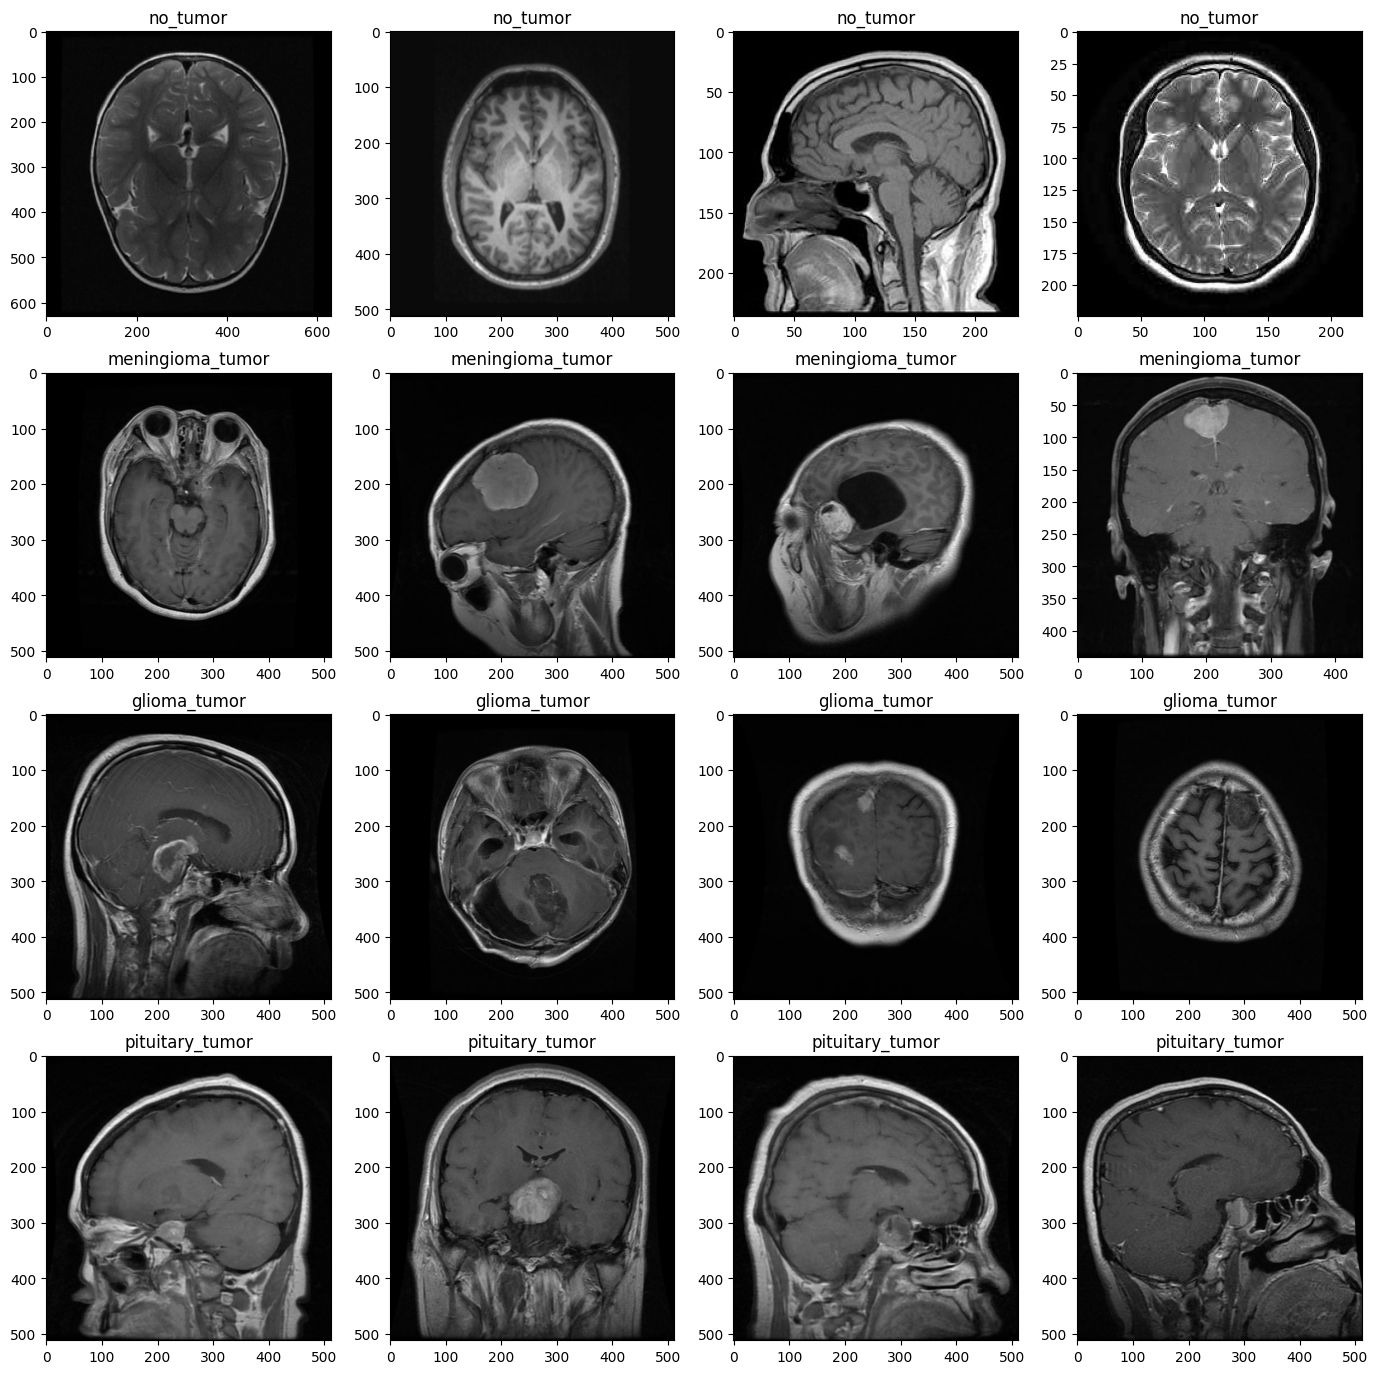

In [25]:
# Visualization of training and testing data samples

train_dir = 'Data/Training/'
test_dir = 'Data/Testing/'
classes = os.listdir('Data/Training')

files_path_dict = {}

for c in classes:
  files_path_dict[c] = list(map(lambda x: train_dir + c + '/' + x, os.listdir(train_dir + c)))

plt.figure(figsize = (17,17))
index = 0
for c in classes:
  random.shuffle(files_path_dict[c])
  path_list = files_path_dict[c][:5]

  for i in range(1, 5):
    index += 1
    plt.subplot(4, 4, index)
    plt.imshow(load_img(path_list[i]))
    plt.title(c)

In [40]:
# Check the number of images in each class in the training dataset

No_images_per_class = []
Class_name = []

for i in os.listdir('Data/Training'):
  train_class = os.listdir(os.path.join('Data/Training', i))
  No_images_per_class.append(len(train_class))
  Class_name.append(i)
  print('Number of images in {} = {} \n'.format(i, len(train_class)))

Number of images in no_tumor = 1990 

Number of images in meningioma_tumor = 2161 

Number of images in glioma_tumor = 2147 

Number of images in pituitary_tumor = 2284 



In [38]:
# Check the number of images in each class in the testing dataset

No_images_per_class = []
Class_name = []

for i in os.listdir('Data/Testing'):
  train_class = os.listdir(os.path.join('Data/Testing', i))
  No_images_per_class.append(len(train_class))
  Class_name.append(i)
  print('Number of images in {} = {} \n'.format(i, len(train_class)))

Number of images in no_tumor = 510 

Number of images in meningioma_tumor = 421 

Number of images in glioma_tumor = 400 

Number of images in pituitary_tumor = 374 



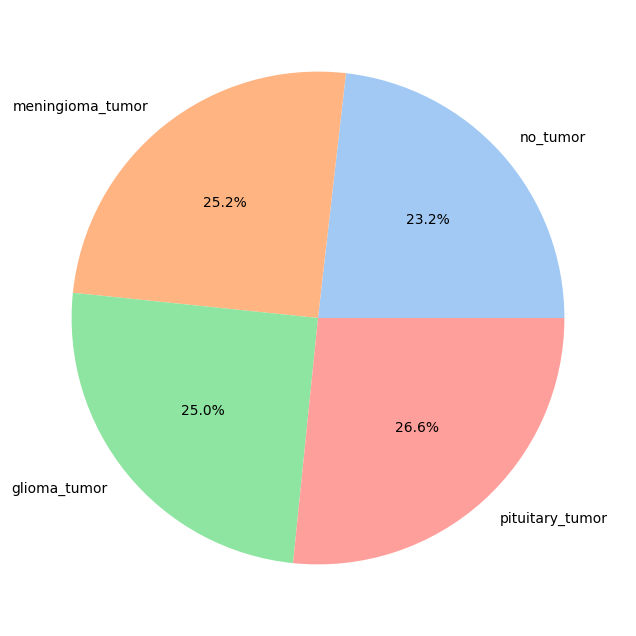

In [41]:
# Visualize class distribution in train set
plt.figure(figsize=(8, 8))
colors = sns.color_palette('pastel')
plt.pie(No_images_per_class, 
        labels = Class_name, 
        autopct = '%1.1f%%',
        colors=colors)
plt.show()

In [42]:
'''
3. Create function to crop images
'''
def crop_image(image, plot=False):
    
    #convert to grayscale
    img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    #blur
    img_gray = cv2.GaussianBlur(img_gray, (5, 5), 0)
    
    #apply binary threshhold
    img_thresh = cv2.threshold(img_gray, 45, 255, cv2.THRESH_BINARY)[1]

    #apply erosion
    img_thresh = cv2.erode(img_thresh, None, iterations=2)

    #dilate images
    img_thresh = cv2.dilate(img_thresh, None, iterations=2)

    #find shapes or the contour of images
    contours = cv2.findContours(img_thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    #grab contours
    contours = imutils.grab_contours(contours)

    #find biggest contour
    c = max(contours, key=cv2.contourArea)

    #extract contour positions
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])
    
    #generate new image
    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]            

    #plot
    if plot:
        plt.figure(figsize=(15, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.tick_params(axis='both', which='both', top=False, bottom=False, left=False, right=False,labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        plt.title('Original Image')
        plt.subplot(1, 2, 2)
        plt.imshow(new_image)
        plt.tick_params(axis='both', which='both',top=False, bottom=False, left=False, right=False,labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        plt.title('Cropped Image')
        plt.show()
    
    return new_image

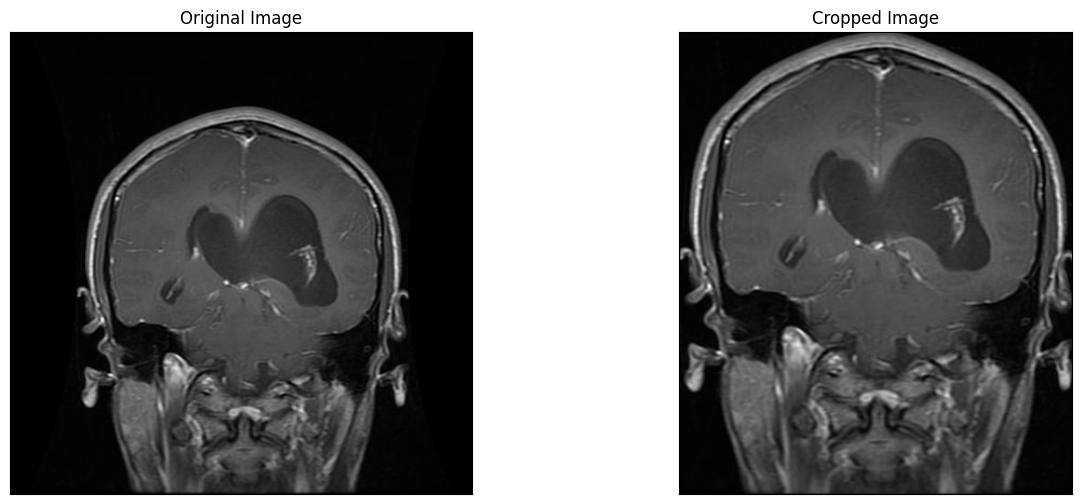

In [43]:
# Example image of pre and post crop function
example_image = cv2.imread('Data/Training/glioma_tumor/g 3.jpg')
cropped_image = crop_image(example_image, plot=True)

In [48]:
# Create directory for cropped training data
os.mkdir('Data/Crop-Training')
os.mkdir('Data/Crop-Training/glioma_tumor')
os.mkdir('Data/Crop-Training/meningioma_tumor')
os.mkdir('Data/Crop-Training/pituitary_tumor')
os.mkdir('Data/Crop-Training/no_tumor')

In [49]:
# Create directory for cropped testing data
os.mkdir('Data/Crop-Testing')
os.mkdir('Data/Crop-Testing/glioma_tumor')
os.mkdir('Data/Crop-Testing/meningioma_tumor')
os.mkdir('Data/Crop-Testing/pituitary_tumor')
os.mkdir('Data/Crop-Testing/no_tumor')

In [50]:
# Crop training images and save to the cropped images folder

glioma = train_dir + 'glioma_tumor'
meningioma = train_dir + 'meningioma_tumor'
pituitary = train_dir + 'pituitary_tumor'
no_tumor = train_dir + 'no_tumor'

j = 0
for i in tqdm(os.listdir(glioma)):
  path = os.path.join(glioma, i)
  img = cv2.imread(path)
  img = crop_image(img, plot=False)

  if img is not None:
    img = cv2.resize(img, (240, 240))
    save_path = 'Data/Crop-Training/glioma_tumor/' + str(j) + '.jpg'
    cv2.imwrite(save_path, img)
    j = j + 1

j = 0
for i in tqdm(os.listdir(meningioma)):
  path = os.path.join(meningioma, i)
  img = cv2.imread(path)
  img = crop_image(img, plot=False)

  if img is not None:
    img = cv2.resize(img, (240, 240))
    save_path = 'Data/Crop-Training/meningioma_tumor/' + str(j) + '.jpg'
    cv2.imwrite(save_path, img)
    j = j + 1  

j = 0
for i in tqdm(os.listdir(pituitary)):
  path = os.path.join(pituitary, i)
  img = cv2.imread(path)
  img = crop_image(img, plot=False)

  if img is not None:
    img = cv2.resize(img, (240, 240))
    save_path = 'Data/Crop-Training/pituitary_tumor/' + str(j) + '.jpg'
    cv2.imwrite(save_path, img)
    j = j + 1  

j = 0
for i in tqdm(os.listdir(no_tumor)):
  path = os.path.join(no_tumor, i)
  img = cv2.imread(path)
  img = crop_image(img, plot=False)

  if img is not None:
    img = cv2.resize(img, (240, 240))
    save_path = 'Data/Crop-Training/no_tumor/' + str(j) + '.jpg'
    cv2.imwrite(save_path, img)
    j = j + 1  

100%|██████████| 1990/1990 [00:02<00:00, 895.41it/s]


In [51]:
# Crop testing images and save it to cropped images folder
test_glioma = test_dir + 'glioma_tumor'
test_meningioma = test_dir + 'meningioma_tumor'
test_pituitary = test_dir + 'pituitary_tumor'
test_no_tumor = test_dir + 'no_tumor'

j = 0
for i in tqdm(os.listdir(test_glioma)):
  path = os.path.join(test_glioma, i)
  img = cv2.imread(path)
  img = crop_image(img, plot=False)

  if img is not None:
    img = cv2.resize(img, (240, 240))
    save_path = 'Data/Crop-Testing/glioma_tumor/' + str(j) + '.jpg'
    cv2.imwrite(save_path, img)
    j = j + 1

j = 0
for i in tqdm(os.listdir(test_meningioma)):
  path = os.path.join(test_meningioma, i)
  img = cv2.imread(path)
  img = crop_image(img, plot=False)

  if img is not None:
    img = cv2.resize(img, (240, 240))
    save_path = 'Data/Crop-Testing/meningioma_tumor/' + str(j) + '.jpg'
    cv2.imwrite(save_path, img)
    j = j + 1  

j = 0
for i in tqdm(os.listdir(test_pituitary)):
  path = os.path.join(test_pituitary, i)
  img = cv2.imread(path)
  img = crop_image(img, plot=False)

  if img is not None:
    img = cv2.resize(img, (240, 240))
    save_path = 'Data/Crop-Testing/pituitary_tumor/' + str(j) + '.jpg'
    cv2.imwrite(save_path, img)
    j = j + 1  

j = 0
for i in tqdm(os.listdir(test_no_tumor)):
  path = os.path.join(test_no_tumor, i)
  img = cv2.imread(path)
  img = crop_image(img, plot=False)

  if img is not None:
    img = cv2.resize(img, (240, 240))
    save_path = 'Data/Crop-Testing/no_tumor/' + str(j) + '.jpg'
    cv2.imwrite(save_path, img)
    j = j + 1  

100%|██████████| 510/510 [00:00<00:00, 1157.64it/s]


In [52]:
'''
4. Data Augmentation
'''

datagen = ImageDataGenerator(rotation_range=10,
                             height_shift_range=0.2,
                             horizontal_flip=True,
                             validation_split=0.2)

train_data = datagen.flow_from_directory('Data/Crop-Training/',
                                         target_size=(240, 240),
                                         batch_size=32,
                                         class_mode='categorical',
                                         subset='training')

valid_data = datagen.flow_from_directory('Data/Crop-Training/',
                                         target_size=(240, 240),
                                         batch_size=32,
                                         class_mode='categorical',
                                         subset='validation')

#test set
test_datagen = ImageDataGenerator()

test_data = datagen.flow_from_directory('Data/Crop-Testing/',
                                         target_size=(240, 240),
                                        class_mode='categorical',
                                        shuffle=False)
                                        

Found 6867 images belonging to 4 classes.
Found 1715 images belonging to 4 classes.
Found 1705 images belonging to 4 classes.


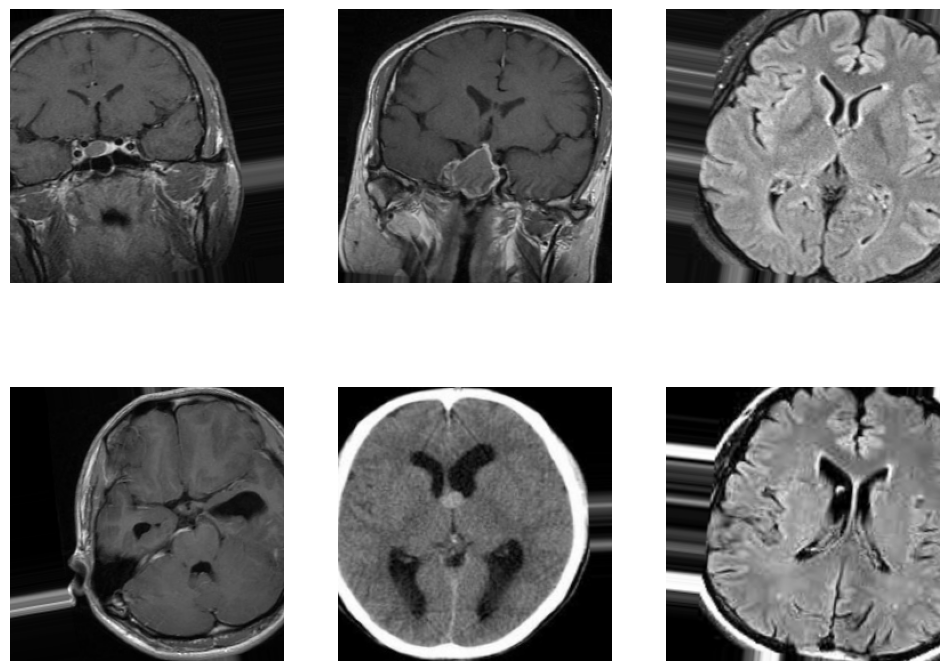

In [54]:
# Examples of the augmented data
sample_x, sample_y = next(train_data)
plt.figure(figsize=(12, 9))
for i in range(6):
  plt.subplot(2, 3, i+1)
  sample = array_to_img(sample_x[i])
  plt.axis('off')
  plt.grid(False)
  plt.imshow(sample)
plt.show()